# Exploring the data

## Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from datetime import datetime
import sys
sys.path.append("utils")
from utils.plot_settings import *

plt.rcParams.update(RCPARAMS)

## Load data

In [3]:
from utils.load_data import load_data

filename = "../data/MrWorldwide.csv"

raw = load_data(filename)

all_titled = raw[raw['Title'].notna()].copy()   # countries with a book selected
read       = raw[raw['Date'].notna()].copy()    # books actually finished
rated      = read[read['Rating'].notna()].copy()

print(f'Total countries in dataset      : {len(raw)-1}')
print(f'Countries with a book lined up  : {len(all_titled)}')
print(f'Books finished (have a date)    : {len(read)}')
print(f'Books with a rating             : {len(rated)}')

Total countries in dataset      : 196
Countries with a book lined up  : 125
Books finished (have a date)    : 36
Books with a rating             : 33


## Basic stats

In [4]:
TOTAL_COUNTRIES = 195
n_read    = len(read)
pct_done  = n_read / TOTAL_COUNTRIES * 100
avg_rating = rated['Rating'].mean()
female_pct = read['Female_Author'].mean() * 100
lang_es    = (read['Language'] == 'Español').sum()
lang_en    = (read['Language'] == 'Inglés').sum()

print('━' * 46)
print(f'  🌍  Countries read       {n_read:>4} / {TOTAL_COUNTRIES}  ({pct_done:.1f}%)')
print(f'  ⭐  Average rating       {avg_rating:.2f} / 5.00')
print(f'  👩  Female authors        {female_pct:.0f}% of books read')
print(f'  🇺🇾  In Spanish            {lang_es} books')
print(f'  🇬🇧  In English            {lang_en} books')
print('━' * 46)

# Progress bar
filled = int(pct_done / 2)
bar    = '█' * filled + '░' * (50 - filled)
print(f'\n  Progress: [{bar}] {pct_done:.1f}%\n')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🌍  Countries read         36 / 195  (18.5%)
  ⭐  Average rating       3.23 / 5.00
  👩  Female authors        39% of books read
  🇺🇾  In Spanish            9 books
  🇬🇧  In English            27 books
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Progress: [█████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 18.5%



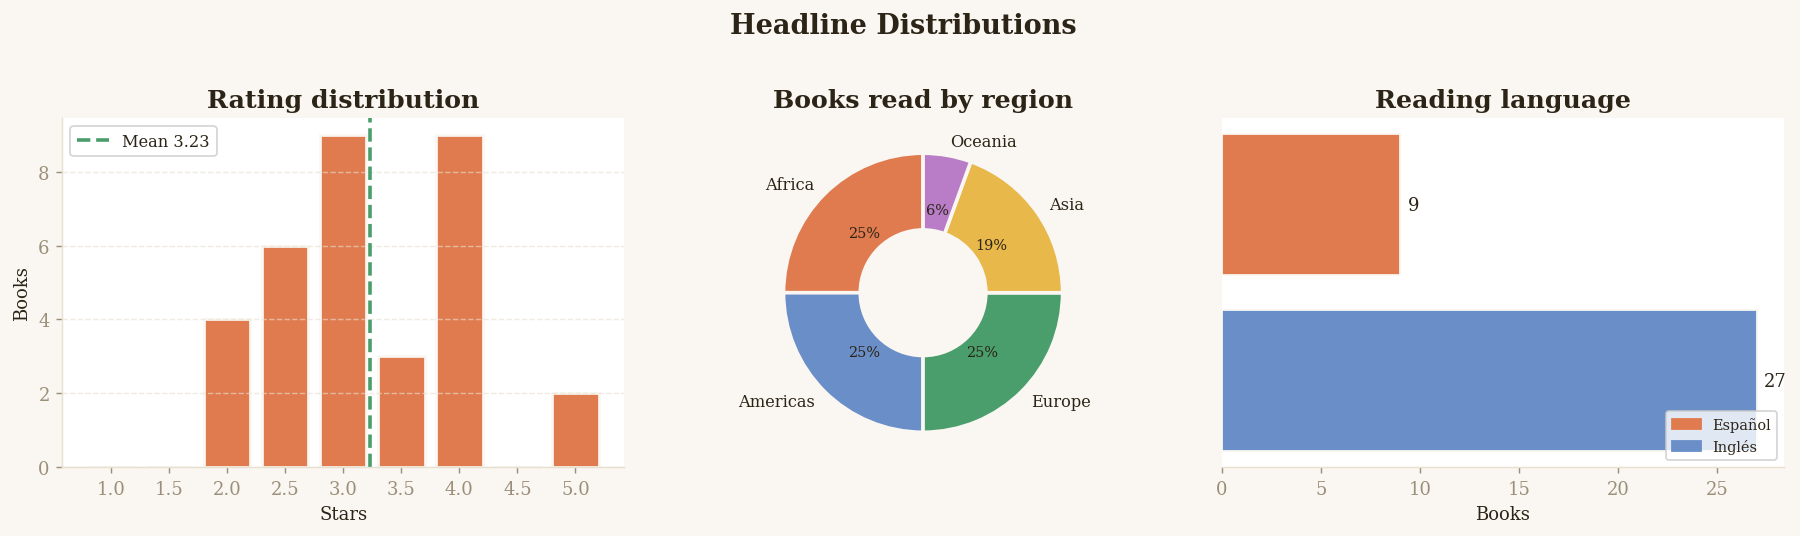

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Headline Distributions', fontsize=15, fontweight='bold', y=1.02)

# — Rating histogram ——————————————————————————————————————————
ax = axes[0]
bins = [0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25, 4.75, 5.25]
ax.hist(rated['Rating'], bins=bins, color=ACCENT, edgecolor=BG, linewidth=1.5, rwidth=0.8)
ax.axvline(avg_rating, color=GREEN, linewidth=2, linestyle='--', label=f'Mean {avg_rating:.2f}')
ax.legend(fontsize=9)
ax.set_title('Rating distribution')
ax.set_xlabel('Stars')
ax.set_ylabel('Books')
ax.set_xticks([1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5])
ax.grid(axis='y')
ax.spines[['top','right']].set_visible(False)

# — Region donut ——————————————————————————————————————————————
ax = axes[1]
reg_counts = read['Region'].value_counts()
colors     = [PALETTE.get(r, '#ccc') for r in reg_counts.index]
wedges, texts, autotexts = ax.pie(
    reg_counts, labels=reg_counts.index, colors=colors,
    autopct='%1.0f%%', startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': BG, 'linewidth': 2},
    textprops={'fontsize': 9},
)
for at in autotexts: at.set_fontsize(8)
ax.set_title('Books read by region')

# — Language bar ——————————————————————————————————————————————
ax = axes[2]
lang_counts = read['Language'].value_counts()
lang_colors = [ACCENT if l == 'Español' else '#6a8fc8' for l in lang_counts.index]
bars = ax.barh(lang_counts.index, lang_counts.values,
               color=lang_colors, edgecolor=BG, linewidth=1)
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_title('Reading language')
ax.set_xlabel('Books')
ax.spines[['top','right','left']].set_visible(False)
ax.set_yticks([])
patches = [mpatches.Patch(color=ACCENT, label='Español'),
           mpatches.Patch(color='#6a8fc8', label='Inglés')]
ax.legend(handles=patches, fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

## Reading pace

Books over time.

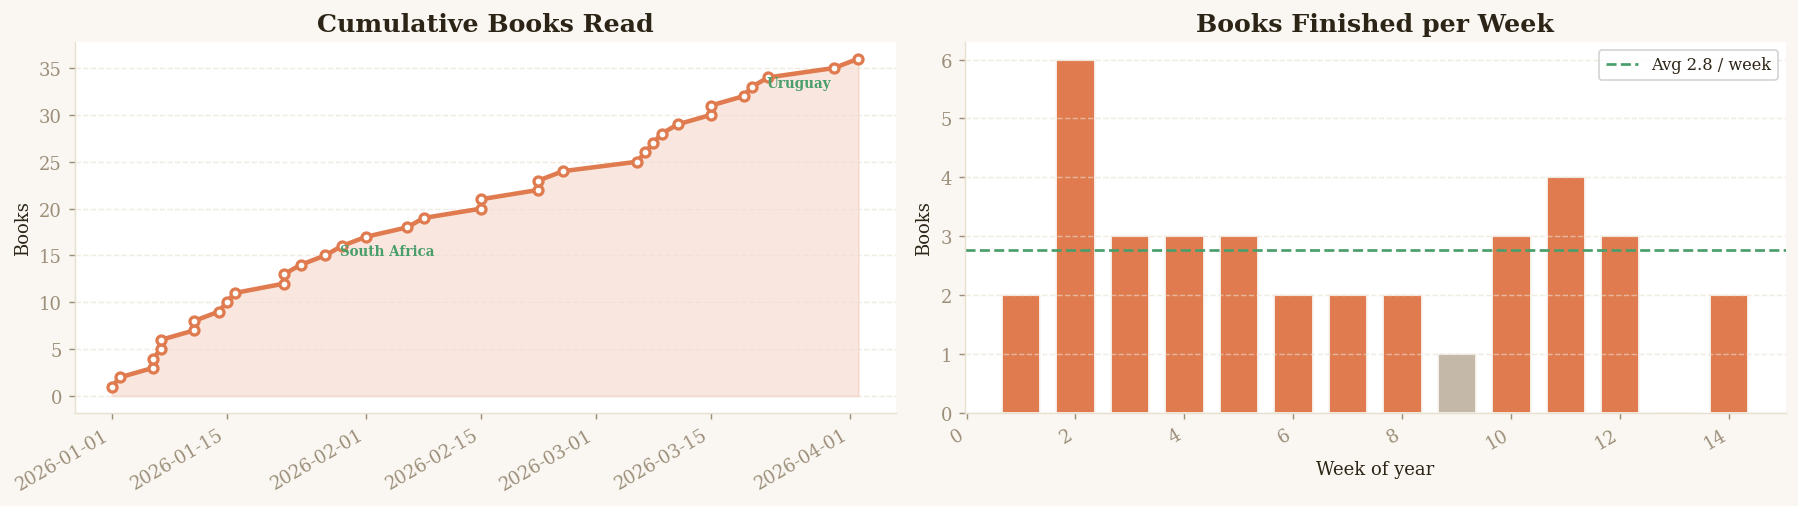

Average pace : 2.77 books / week
At this rate : 70 weeks to complete all 195 (~1.4 years)


In [ ]:
timeline = read.sort_values('Date').copy()
timeline['Book_Number'] = range(1, len(timeline) + 1)
timeline['Week'] = timeline['Date'].dt.isocalendar().week.astype(int)
timeline['Month'] = timeline['Date'].dt.to_period('M').astype(str)

# Books per week
per_week  = timeline.groupby('Week').size().reset_index(name='n')
full_weeks = pd.DataFrame({'Week': range(per_week['Week'].min(), per_week['Week'].max() + 1)})
per_week  = full_weeks.merge(per_week, on='Week', how='left').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# — Cumulative ————————————————————————————————————————————————
ax = axes[0]
ax.fill_between(timeline['Date'], timeline['Book_Number'],
                alpha=0.18, color=ACCENT)
ax.plot(timeline['Date'], timeline['Book_Number'],
        color=ACCENT, linewidth=2.5, marker='o', markersize=5,
        markerfacecolor=SURFACE, markeredgewidth=1.8)

# Annotate faves (rating == 5)
for _, row in timeline[timeline['Rating'] == 5].iterrows():
    ax.annotate(row['Country'], xy=(row['Date'], row['Book_Number']),
                xytext=(8, 0), textcoords='offset points',
                fontsize=7.5, color=GREEN, fontweight='bold')

ax.set_title('Cumulative Books Read')
ax.set_xlabel('')
ax.set_ylabel('Books')
ax.grid(axis='y')
ax.spines[['top','right']].set_visible(False)
fig.autofmt_xdate(rotation=30)

# — Books per week bar ————————————————————————————————————————
ax = axes[1]
bar_colors = [ACCENT if n >= 2 else '#c4b8a8' for n in per_week['n']]
ax.bar(per_week['Week'], per_week['n'], color=bar_colors,
       edgecolor=BG, linewidth=1, width=0.7)
mean_pw = timeline.groupby('Week').size().mean()
ax.axhline(mean_pw, color=GREEN, linestyle='--', linewidth=1.5,
           label=f'Avg {mean_pw:.1f} / week')
ax.legend(fontsize=9)
ax.set_title('Books Finished per Week')
ax.set_xlabel('Week of year')
ax.set_ylabel('Books')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis='y')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

avg_per_week = n_read / max(per_week['Week'].max() - per_week['Week'].min(), 1)
projected    = TOTAL_COUNTRIES / avg_per_week if avg_per_week > 0 else float('inf')
print(f'Average pace : {avg_per_week:.2f} books / week')
print(f'At this rate : {projected:.0f} weeks to complete all 195 (~{projected/52:.1f} years)')

## Region deep-dive

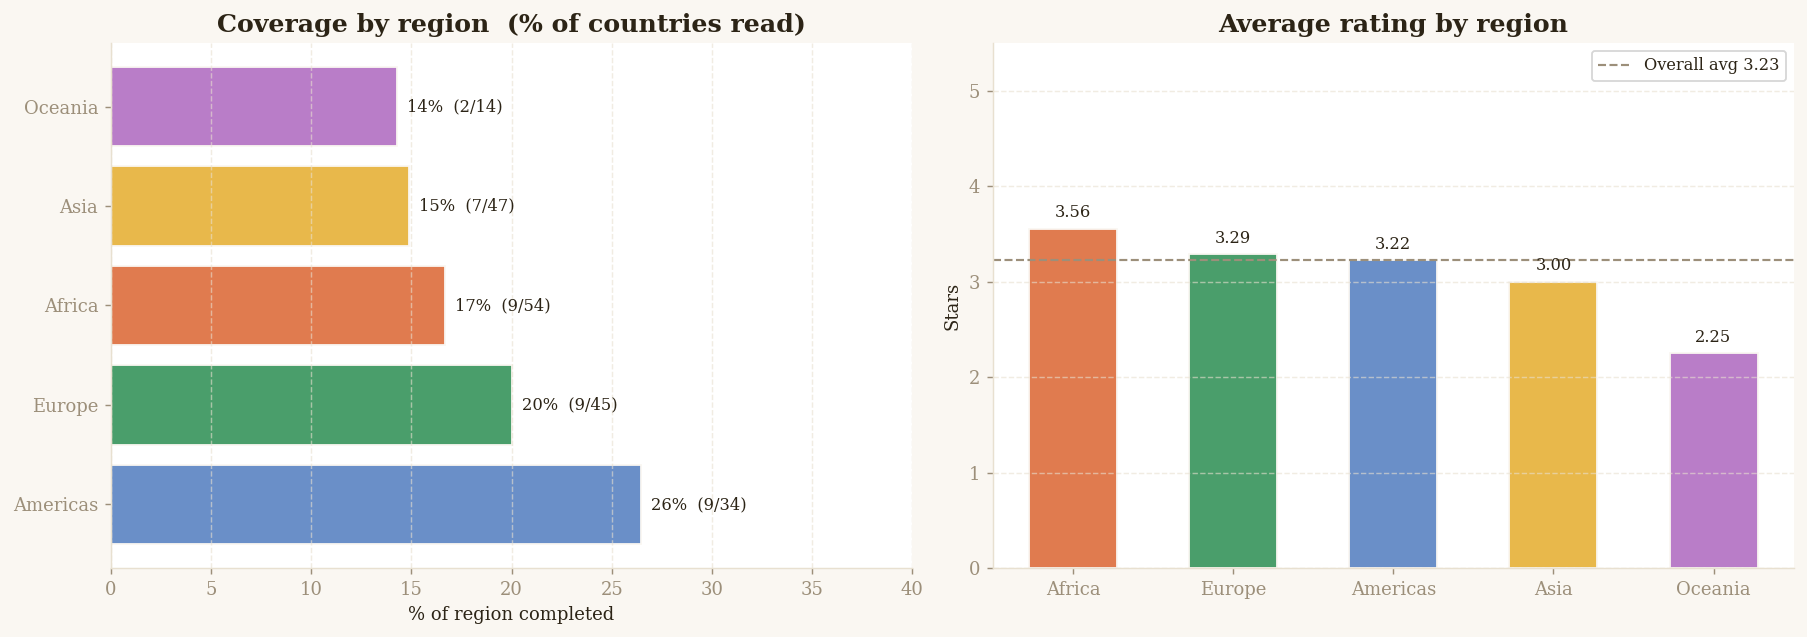

In [ ]:
# Countries per region (total)
total_per_region = raw['Region'].value_counts()
read_per_region  = read['Region'].value_counts()
pct_per_region   = (read_per_region / total_per_region * 100).sort_values(ascending=False)

# Average rating per region
avg_rat_region = rated.groupby('Region')['Rating'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Coverage % ————————————————————————————————————————————————
ax = axes[0]
regions_sorted = pct_per_region.index
colors = [PALETTE.get(r, '#ccc') for r in regions_sorted]
bars = ax.barh(regions_sorted, pct_per_region.values,
               color=colors, edgecolor=BG, linewidth=1)
for bar, val, r in zip(bars, pct_per_region.values, regions_sorted):
    read_n = int(read_per_region.get(r, 0))
    tot_n  = int(total_per_region.get(r, 0))
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}%  ({read_n}/{tot_n})',
            va='center', fontsize=9)
ax.set_xlim(0, 40)
ax.set_title('Coverage by region  (% of countries read)')
ax.set_xlabel('% of region completed')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x')

# — Avg rating per region ————————————————————————————————————
ax = axes[1]
colors2 = [PALETTE.get(r, '#ccc') for r in avg_rat_region.index]
bars2 = ax.bar(avg_rat_region.index, avg_rat_region.values,
               color=colors2, edgecolor=BG, linewidth=1, width=0.55)
ax.bar_label(bars2, fmt='%.2f', padding=4, fontsize=9)
ax.set_ylim(0, 5.5)
ax.axhline(avg_rating, color=MUTED, linestyle='--', linewidth=1.2,
           label=f'Overall avg {avg_rating:.2f}')
ax.legend(fontsize=9)
ax.set_title('Average rating by region')
ax.set_ylabel('Stars')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y')

plt.tight_layout()
plt.show()

## Author sex

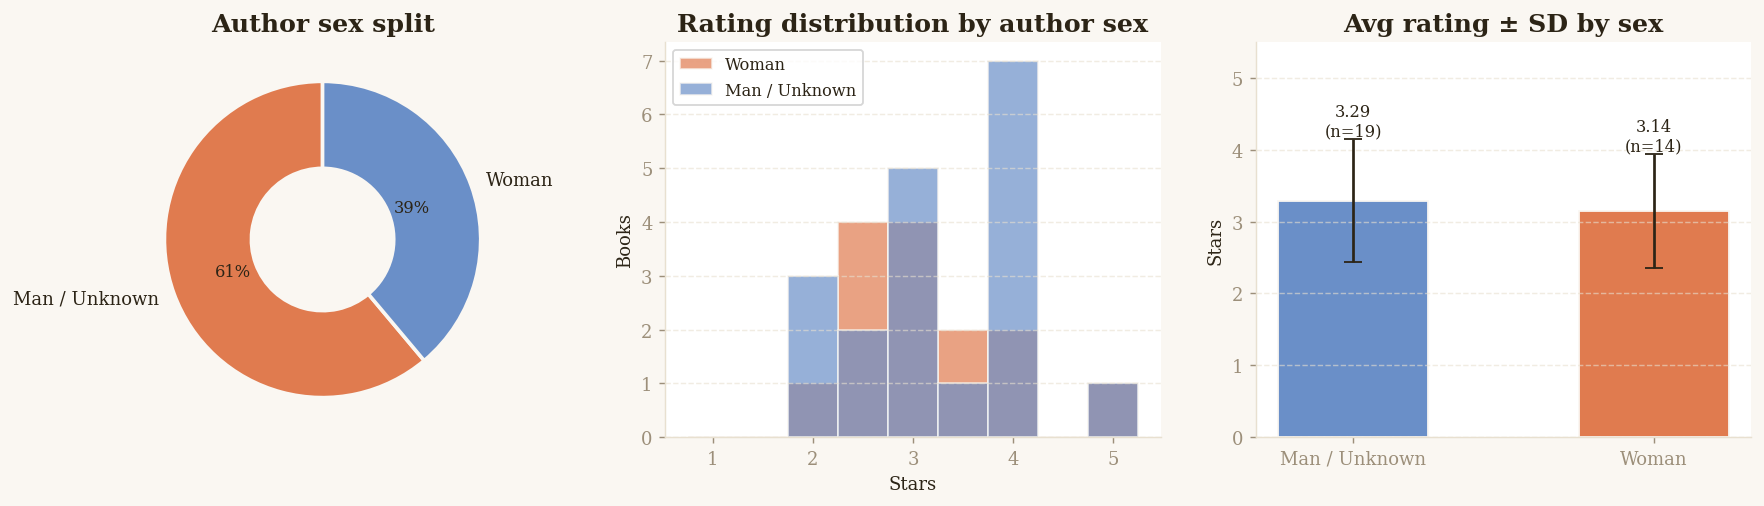

  Man / Unknown       avg rating = 3.29  (n=19)
  Woman               avg rating = 3.14  (n=14)


In [ ]:
read['Author_Gender'] = read['Female_Author'].map({1: 'Woman', 0: 'Man / Unknown'})
gender_counts  = read['Author_Gender'].value_counts()
gender_ratings = rated.copy()
gender_ratings['Author_Gender'] = gender_ratings['Female_Author'].map({1:'Woman', 0:'Man / Unknown'})

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# — Split donut ————————————————————————————————————————————————
ax = axes[0]
g_colors = ['#e07b4f', '#6a8fc8']
wedges, texts, autos = ax.pie(
    gender_counts, labels=gender_counts.index, colors=g_colors,
    autopct='%1.0f%%', startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': BG, 'linewidth': 2},
)
for at in autos: at.set_fontsize(9)
ax.set_title('Author sex split')

# — Rating distribution by gender ————————————————————————————
ax = axes[1]
for gender, color in zip(['Woman', 'Man / Unknown'], g_colors):
    subset = gender_ratings[gender_ratings['Author_Gender'] == gender]['Rating']
    if len(subset):
        ax.hist(subset, bins=np.arange(0.75, 5.5, 0.5),
                alpha=0.7, color=color, label=gender, edgecolor=BG)
ax.legend(fontsize=9)
ax.set_title('Rating distribution by author sex')
ax.set_xlabel('Stars')
ax.set_ylabel('Books')
ax.grid(axis='y')
ax.spines[['top','right']].set_visible(False)

# — Avg rating boxes ——————————————————————————————————————————
ax = axes[2]
group_avgs = gender_ratings.groupby('Author_Gender')['Rating'].agg(['mean','std','count'])
for i, (gender, row) in enumerate(group_avgs.iterrows()):
    color = '#e07b4f' if gender == 'Woman' else '#6a8fc8'
    ax.bar(i, row['mean'], color=color, width=0.5, edgecolor=BG)
    ax.errorbar(i, row['mean'], yerr=row['std'], fmt='none',
                color=TEXT, capsize=5, linewidth=1.5)
    ax.text(i, row['mean'] + row['std'] + 0.05,
            f"{row['mean']:.2f}\n(n={int(row['count'])})",
            ha='center', fontsize=9)
ax.set_xticks([0, 1])
ax.set_xticklabels(group_avgs.index)
ax.set_ylim(0, 5.5)
ax.set_title('Avg rating ± SD by sex')
ax.set_ylabel('Stars')
ax.grid(axis='y')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

for gender, row in group_avgs.iterrows():
    print(f"  {gender:<18}  avg rating = {row['mean']:.2f}  (n={int(row['count'])})")

## Genre landscape

/var/folders/25/trn790712rv7c3hck08g1sym0000gn/T/ipykernel_43499/1792044011.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('RdYlGn', len(genre_counts))


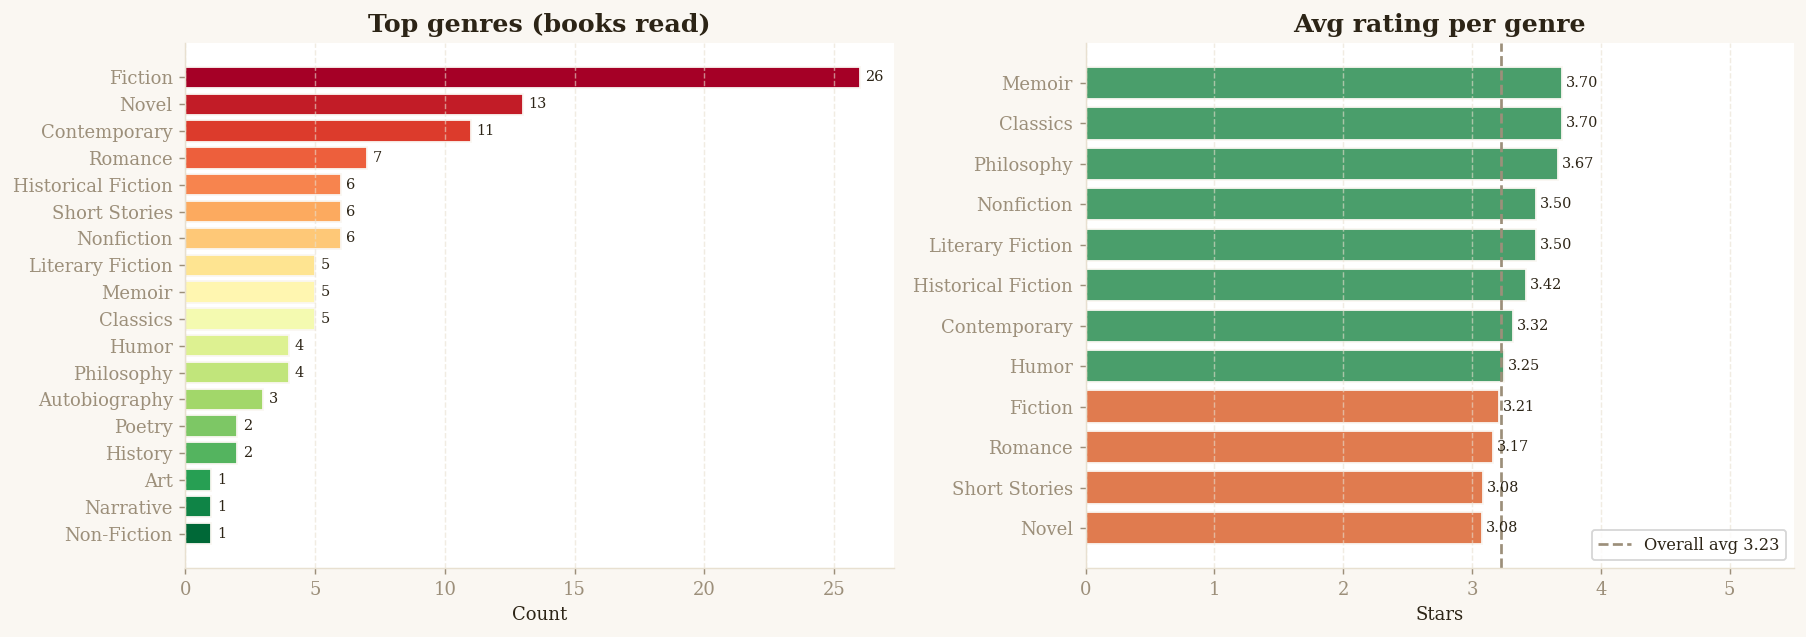

In [9]:
# Explode comma-separated genres
genres_raw = read['Genre'].dropna().str.split(',').explode()
genres_raw = genres_raw.str.strip()
genre_counts = genres_raw.value_counts().head(18)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Horizontal bar chart ——————————————————————————————————————
ax = axes[0]
cmap   = plt.cm.get_cmap('RdYlGn', len(genre_counts))
gcolors = [cmap(i / len(genre_counts)) for i in range(len(genre_counts))]
bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1],
               color=gcolors[::-1], edgecolor=BG, linewidth=1)
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_title('Top genres (books read)')
ax.set_xlabel('Count')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x')

# — Avg rating per genre ——————————————————————————————————————
ax = axes[1]
# Rebuild with ratings
rated_genres = rated.copy()
rated_genres['Genre_list'] = rated_genres['Genre'].str.split(',')
rated_genres = rated_genres.dropna(subset=['Genre_list'])
genre_rows = []
for _, row in rated_genres.iterrows():
    for g in row['Genre_list']:
        genre_rows.append({'Genre': g.strip(), 'Rating': row['Rating']})
gdf = pd.DataFrame(genre_rows)
top_genres = genre_counts.index[:12]
gdf_top    = gdf[gdf['Genre'].isin(top_genres)]
g_avg = gdf_top.groupby('Genre')['Rating'].mean().sort_values()
g_cnt = gdf_top.groupby('Genre')['Rating'].count()

bar_colors = [GREEN if v >= avg_rating else ACCENT for v in g_avg.values]
bars2 = ax.barh(g_avg.index, g_avg.values,
                color=bar_colors, edgecolor=BG, linewidth=1)
ax.axvline(avg_rating, color=MUTED, linestyle='--', linewidth=1.5,
           label=f'Overall avg {avg_rating:.2f}')
for bar, val in zip(bars2, g_avg.values):
    ax.text(val + 0.03, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=8)
ax.legend(fontsize=9)
ax.set_title('Avg rating per genre')
ax.set_xlabel('Stars')
ax.set_xlim(0, 5.5)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x')

plt.tight_layout()
plt.show()

##  Rating over time

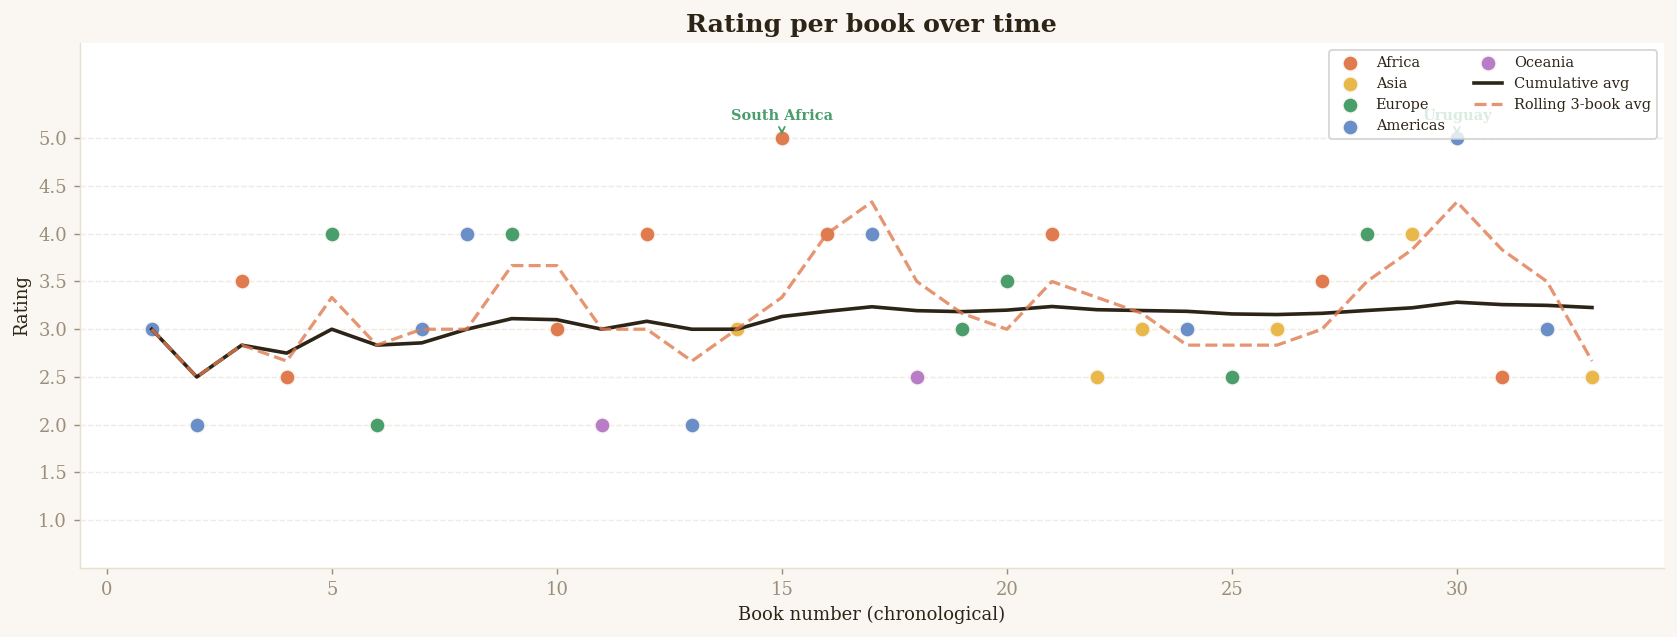

Trend slope: +0.0114 stars / book  → getting more generous 📈 over time


In [13]:
rt = rated.sort_values('Date').copy()
rt['Book_N']       = range(1, len(rt) + 1)
rt['Rolling_Avg']  = rt['Rating'].expanding().mean()
rt['Rolling_3']    = rt['Rating'].rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 5))

# Scatter coloured by region
for region, color in PALETTE.items():
    sub = rt[rt['Region'] == region]
    ax.scatter(sub['Book_N'], sub['Rating'], color=color, s=70,
               zorder=3, label=region, edgecolors=BG, linewidth=0.8)

# Rolling average lines
ax.plot(rt['Book_N'], rt['Rolling_Avg'], color=TEXT, linewidth=2,
        linestyle='-', label='Cumulative avg', zorder=4)
ax.plot(rt['Book_N'], rt['Rolling_3'], color=ACCENT, linewidth=1.8,
        linestyle='--', alpha=0.8, label='Rolling 3-book avg', zorder=4)

# Annotate best books
for _, row in rt[rt['Rating'] == 5].iterrows():
    ax.annotate(row['Country'],
                xy=(row['Book_N'], row['Rating']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8, color=GREEN, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=GREEN, lw=1))

ax.set_title('Rating per book over time', fontsize=14)
ax.set_xlabel('Book number (chronological)')
ax.set_ylabel('Rating')
ax.set_ylim(0.5, 6)
ax.set_yticks([1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5])
ax.grid(axis='y')
ax.spines[['top','right']].set_visible(False)
ax.legend(fontsize=8, loc='upper right', ncol=2)

plt.tight_layout()
plt.show()

from numpy.polynomial.polynomial import polyfit
coeffs = polyfit(rt['Book_N'], rt['Rating'], 1)
slope  = coeffs[1]
direction = 'more generous 📈' if slope > 0 else 'pickier 📉'
print(f'Trend slope: {slope:+.4f} stars / book  → getting {direction} over time')

## Reading streaks

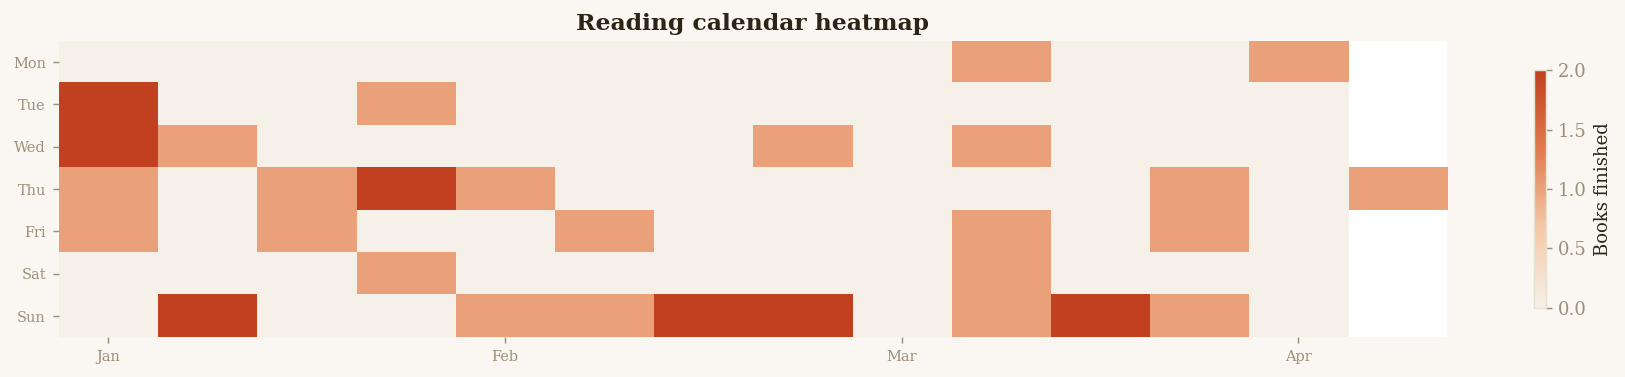

In [11]:
# Build a daily count series for the year
if len(read) > 1:
    year_start = read['Date'].min().replace(month=1, day=1)
    year_end   = datetime(2025, 12, 31) if read['Date'].max().year == 2025 else read['Date'].max()
    date_range = pd.date_range(year_start, year_end, freq='D')
    daily = read.groupby('Date').size().reindex(date_range, fill_value=0)

    # Build a grid: rows = weekday, cols = week number
    weeks = (daily.index - daily.index[0]).days // 7
    weekdays = daily.index.dayofweek  # 0=Mon

    n_weeks = weeks.max() + 1
    grid    = np.zeros((7, n_weeks))
    grid[:] = np.nan

    for val, w, wd in zip(daily.values, weeks, weekdays):
        grid[wd, w] = val

    fig, ax = plt.subplots(figsize=(14, 3))

    # Custom colormap: white → accent
    from matplotlib.colors import LinearSegmentedColormap
    cmap_custom = LinearSegmentedColormap.from_list(
        'reading', ['#f5f0e8', '#f5c9a8', ACCENT, '#c04020'], N=256
    )

    im = ax.imshow(grid, cmap=cmap_custom, aspect='auto',
                   vmin=0, vmax=max(daily.max(), 1),
                   interpolation='nearest')

    ax.set_yticks(range(7))
    ax.set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], fontsize=8)

    # Month labels on x-axis
    month_positions = {}
    for d, w in zip(daily.index, weeks):
        if d.day == 1:
            month_positions[w] = d.strftime('%b')
    ax.set_xticks(list(month_positions.keys()))
    ax.set_xticklabels(list(month_positions.values()), fontsize=8)

    plt.colorbar(im, ax=ax, orientation='vertical',
                 label='Books finished', shrink=0.8)
    ax.set_title('Reading calendar heatmap', fontsize=13)
    ax.spines[:].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print('Not enough dates for a heatmap yet')